Module 21 – KNN Case Study on Diabetes
Aim

Build a Diabetes Prediction Model using the K-Nearest Neighbors (KNN) algorithm.

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

2. Load the Dataset

 the diabetes.csv dataset from Kaggle 

In [26]:
df = pd.read_csv("diabetes.csv")

3. Explore the Dataset
View first five rows

In [27]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset Information

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Dataset Shape

In [29]:
print("Rows and Columns:", df.shape)

Rows and Columns: (768, 9)


Check Missing Values

In [30]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Statistical Summary

In [31]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


4. Data Preprocessing

In this dataset, some columns contain 0, which is not a valid value.

Replace 0 with the median value.

In [32]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    df[col] = df[col].replace(0, df[col].median())

Check again.

In [33]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


5. Separate Features and Target

In [34]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

6. Normalize the Features

In [35]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

7. Split the Dataset

80% Training

20% Testing

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

8. Train the KNN Model

Choose k = 5

In [37]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


9. Make Predictions

In [38]:
y_pred = knn.predict(X_test)

10. Evaluate the Model
Accuracy

In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7467532467532467


Confusion Matrix

In [40]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[79 20]
 [19 36]]


Classification Report

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80        99
           1       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



11. Plot Confusion Matrix

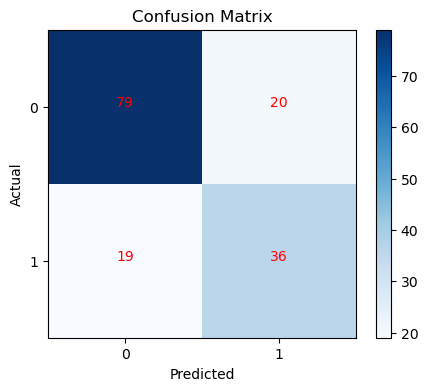

In [42]:
plt.figure(figsize=(5,4))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks([0,1])

plt.yticks([0,1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', color='red')

plt.show()

12. Test Different K Values

In [43]:
accuracy_list = []

for k in range(1, 21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy_list.append(accuracy_score(y_test, pred))

13. Plot Accuracy vs K

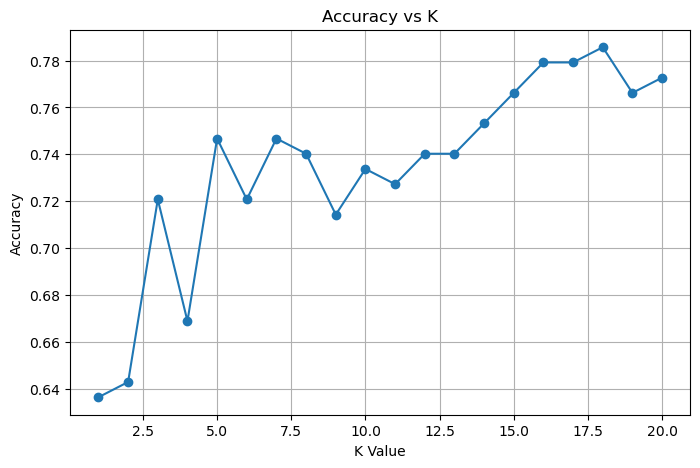

In [44]:
plt.figure(figsize=(8,5))

plt.plot(range(1,21), accuracy_list, marker='o')

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Accuracy vs K")

plt.grid(True)

plt.show()